In [2]:
!uv pip install biotite hydride pandas biopandas

Resolved 20 packages in 281ms                                        
Installed 20 packages in 618ms                              
 + biopandas==0.5.1
 + biotite==1.7.1
 + biotraj==1.2.2
 + certifi==2026.7.22
 + charset-normalizer==3.4.9
 + hydride==1.2.3
 + idna==3.18
 + looseversion==1.1.2
 + mmtf-python==1.1.3
 + msgpack==1.2.1
 + networkx==3.6.1
 + numpy==2.5.1
 + packaging==26.2
 + pandas==3.0.5
 + python-dateutil==2.9.0.post0
 + requests==2.34.2
 + scipy==1.18.0
 + setuptools==83.0.0
 + six==1.17.0
 + urllib3==2.7.0


In [3]:
import os
import glob
import re
import subprocess
import warnings
import numpy as np
import pandas as pd
from biopandas.pdb import PandasPdb
import biotite.structure.io.pdb as pdb
import biotite.structure as stripe
import hydride

warnings.filterwarnings("ignore", category=UserWarning, module="hydride")

def parse_phoptnn_output(search_dir):
    """Dynamically finds and parses pHoptNN's predicted_pH_opt from CSV files."""
    csv_candidates = glob.glob(os.path.join(search_dir, "**", "*.csv"), recursive=True) + \
                    glob.glob("./pred_out/*.csv")
    
    for csv_file in csv_candidates:
        if "predictions" in csv_file or "pred" in csv_file:
            try:
                df_ph = pd.read_csv(csv_file)
                for col in ['predicted_pH_opt', 'pH_opt', 'pred_pH']:
                    if col in df_ph.columns:
                        return float(df_ph[col].iloc[0])
                if len(df_ph.columns) >= 2:
                    return float(df_ph.iloc[0, 1])
            except Exception:
                continue
    return None

def inject_directional_noise(input_pdb, output_pdb, axis='X', sigma=0.0):
    """Injects 1D Gaussian coordinate perturbation along a specified axis."""
    ppdb = PandasPdb().read_pdb(input_pdb)
    coord_col = f"{axis.lower()}_coord"
    
    if sigma > 0.0:
        noise = np.random.normal(0, sigma, len(ppdb.df['ATOM']))
        ppdb.df['ATOM'][coord_col] += noise
        if not ppdb.df['HETATM'].empty:
            het_noise = np.random.normal(0, sigma, len(ppdb.df['HETATM']))
            ppdb.df['HETATM'][coord_col] += het_noise
            
    ppdb.to_pdb(path=output_pdb, records=['ATOM', 'HETATM'])

def compute_propka_mae(ref_pka_path, noisy_pka_path):
    """Parses .pka output files and calculates Mean Absolute Error."""
    def parse_pka(pka_file):
        pkas = {}
        with open(pka_file, 'r') as f:
            for line in f:
                if "SUMMARY OF SUMMARY" in line or "SUMMARY OF THIS REGION" in line:
                    continue
                match = re.search(r'([A-Z]{3})\s+(\d+)\s+([A-Z])?\s+(\d+\.\d+)', line)
                if match:
                    res, num, chain, pka = match.groups()
                    key = f"{res}{num}{chain if chain else ''}"
                    pkas[key] = float(pka)
        return pkas

    ref_pkas = parse_pka(ref_pka_path)
    noisy_pkas = parse_pka(noisy_pka_path)
    
    common_keys = set(ref_pkas.keys()).intersection(set(noisy_pkas.keys()))
    if not common_keys:
        return None
    
    errors = [abs(ref_pkas[k] - noisy_pkas[k]) for k in common_keys]
    return float(np.mean(errors))


# Setup Reference Structure for Hydride Comparison
ground_truth_pdb = "1c57.pdb"
ground_truth_pka = "1c57.pka"

ref_file = pdb.PDBFile.read(ground_truth_pdb)
ref_struct = ref_file.get_structure(model=1)
ref_hydrogens = ref_struct[ref_struct.element == "H"]

# Run PROPKA baseline
if not os.path.exists(ground_truth_pka):
    subprocess.run(["propka3", ground_truth_pdb], capture_output=True)

# Run pHoptNN Baseline on clean structure
custom_env = os.environ.copy()
pqr_bin_paths = ["/home/ol6/miniconda/envs/stress_strain_env/bin", "/home/ol6/miniconda/bin"]
custom_env["PATH"] = ":".join(pqr_bin_paths) + ":" + custom_env.get("PATH", "")

print("Getting baseline pHoptNN prediction for clean structure...")
subprocess.run(["python", "phoptnn_interface.py", ground_truth_pdb], capture_output=True, text=True, env=custom_env)
baseline_phoptnn = parse_phoptnn_output("/home/ol6/subhkl/pHoptNN")
print(f"Clean 1C57 Baseline pHoptNN: {baseline_phoptnn}\n")


# Main Benchmark Loop

stress_levels = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
chosen_axis = 'X'
experiment_data = []

for s in stress_levels:
    temp_pdb = f"1c57_stressed_{s}A.pdb"
    
    # Inject Noise
    inject_directional_noise(ground_truth_pdb, temp_pdb, axis=chosen_axis, sigma=s)
        
    # PROPKA pKa Calculation
    pka_error = None
    try:
        subprocess.run(["propka3", temp_pdb], capture_output=True, text=True)
        noisy_pka_file = f"1c57_stressed_{s}A.pka"
        if os.path.exists(noisy_pka_file):
            pka_error = compute_propka_mae(ground_truth_pka, noisy_pka_file)
            os.remove(noisy_pka_file)
    except Exception:
        pka_error = None

    # pHoptNN Execution & pH_opt Calculation
    cmd = ["python", "phoptnn_interface.py", temp_pdb]
    result = subprocess.run(cmd, capture_output=True, text=True, env=custom_env)
    
    noisy_phoptnn = parse_phoptnn_output("/home/ol6/subhkl/pHoptNN")
    
    if noisy_phoptnn is not None and baseline_phoptnn is not None:
        rmsd_phoptnn = abs(noisy_phoptnn - baseline_phoptnn)
    else:
        rmsd_phoptnn = None

    # Hydride Execution & Hydrogen RMSD
    rmsd_hydride = None
    try:
        pdb_file = pdb.PDBFile.read(temp_pdb)
        atoms = pdb_file.get_structure(model=1)
        atoms_no_h = atoms[atoms.element != "H"]
        atoms_no_h.bonds = stripe.connect_via_distances(atoms_no_h)
        atoms_no_h.set_annotation("charge", np.zeros(len(atoms_no_h), dtype=int))
        
        atoms_with_h, _ = hydride.add_hydrogen(atoms_no_h)
        pred_hydrogens = atoms_with_h[atoms_with_h.element == "H"]
        
        if len(pred_hydrogens) == len(ref_hydrogens) and len(ref_hydrogens) > 0:
            rmsd_hydride = float(stripe.rmsd(ref_hydrogens, pred_hydrogens))
        else:
            rmsd_hydride = float(stripe.rmsd(atoms_no_h, ref_struct[ref_struct.element != "H"]))
            
    except Exception:
        rmsd_hydride = None

    # Logging
    print(f"Sigma: {s}Å | PROPKA ΔpKa: {pka_error} | Hydride RMSD: {rmsd_hydride} | pHoptNN ΔpH: {rmsd_phoptnn}")
    
    experiment_data.append({
        "Stress (Blur Radius Å)": s,
        "PROPKA pKa Error (ΔpH)": pka_error,
        "Hydride H-RMSD (Å)": rmsd_hydride,
        "pHoptNN Error": rmsd_phoptnn,
    })
    
    # Cleanup
    if os.path.exists(temp_pdb):
        os.remove(temp_pdb)


df_final = pd.DataFrame(experiment_data)


output_dir = "data/outputs"
os.makedirs(output_dir, exist_ok=True)

# Export to CSV
csv_filename = os.path.join(output_dir, "phase2_directional_anisotropic.csv")
df_final.to_csv(csv_filename, index=False)

print(f"\n Successfully exported benchmark results to '{csv_filename}'.")

Getting baseline pHoptNN prediction for clean structure...
Clean 1C57 Baseline pHoptNN: 7.381110206076502

Sigma: 0.0Å | PROPKA ΔpKa: 0.0021666666666666644 | Hydride RMSD: 0.0 | pHoptNN ΔpH: 0.0
Sigma: 0.25Å | PROPKA ΔpKa: 0.3491525423728814 | Hydride RMSD: 0.24487201869487762 | pHoptNN ΔpH: 0.0
Sigma: 0.5Å | PROPKA ΔpKa: 0.5706896551724138 | Hydride RMSD: 0.49715766310691833 | pHoptNN ΔpH: 0.0
Sigma: 0.75Å | PROPKA ΔpKa: 0.568448275862069 | Hydride RMSD: 0.7486206889152527 | pHoptNN ΔpH: 0.0
Sigma: 1.0Å | PROPKA ΔpKa: None | Hydride RMSD: 0.9929726719856262 | pHoptNN ΔpH: 0.0
Sigma: 1.25Å | PROPKA ΔpKa: 0.6140350877192985 | Hydride RMSD: 1.2586146593093872 | pHoptNN ΔpH: 0.0
Sigma: 1.5Å | PROPKA ΔpKa: 0.78 | Hydride RMSD: 1.5196729898452759 | pHoptNN ΔpH: 0.0
Sigma: 1.75Å | PROPKA ΔpKa: None | Hydride RMSD: 1.7041360139846802 | pHoptNN ΔpH: 0.0
Sigma: 2.0Å | PROPKA ΔpKa: 0.938 | Hydride RMSD: 1.9954169988632202 | pHoptNN ΔpH: 0.0

 Successfully exported benchmark results to 'data/outp

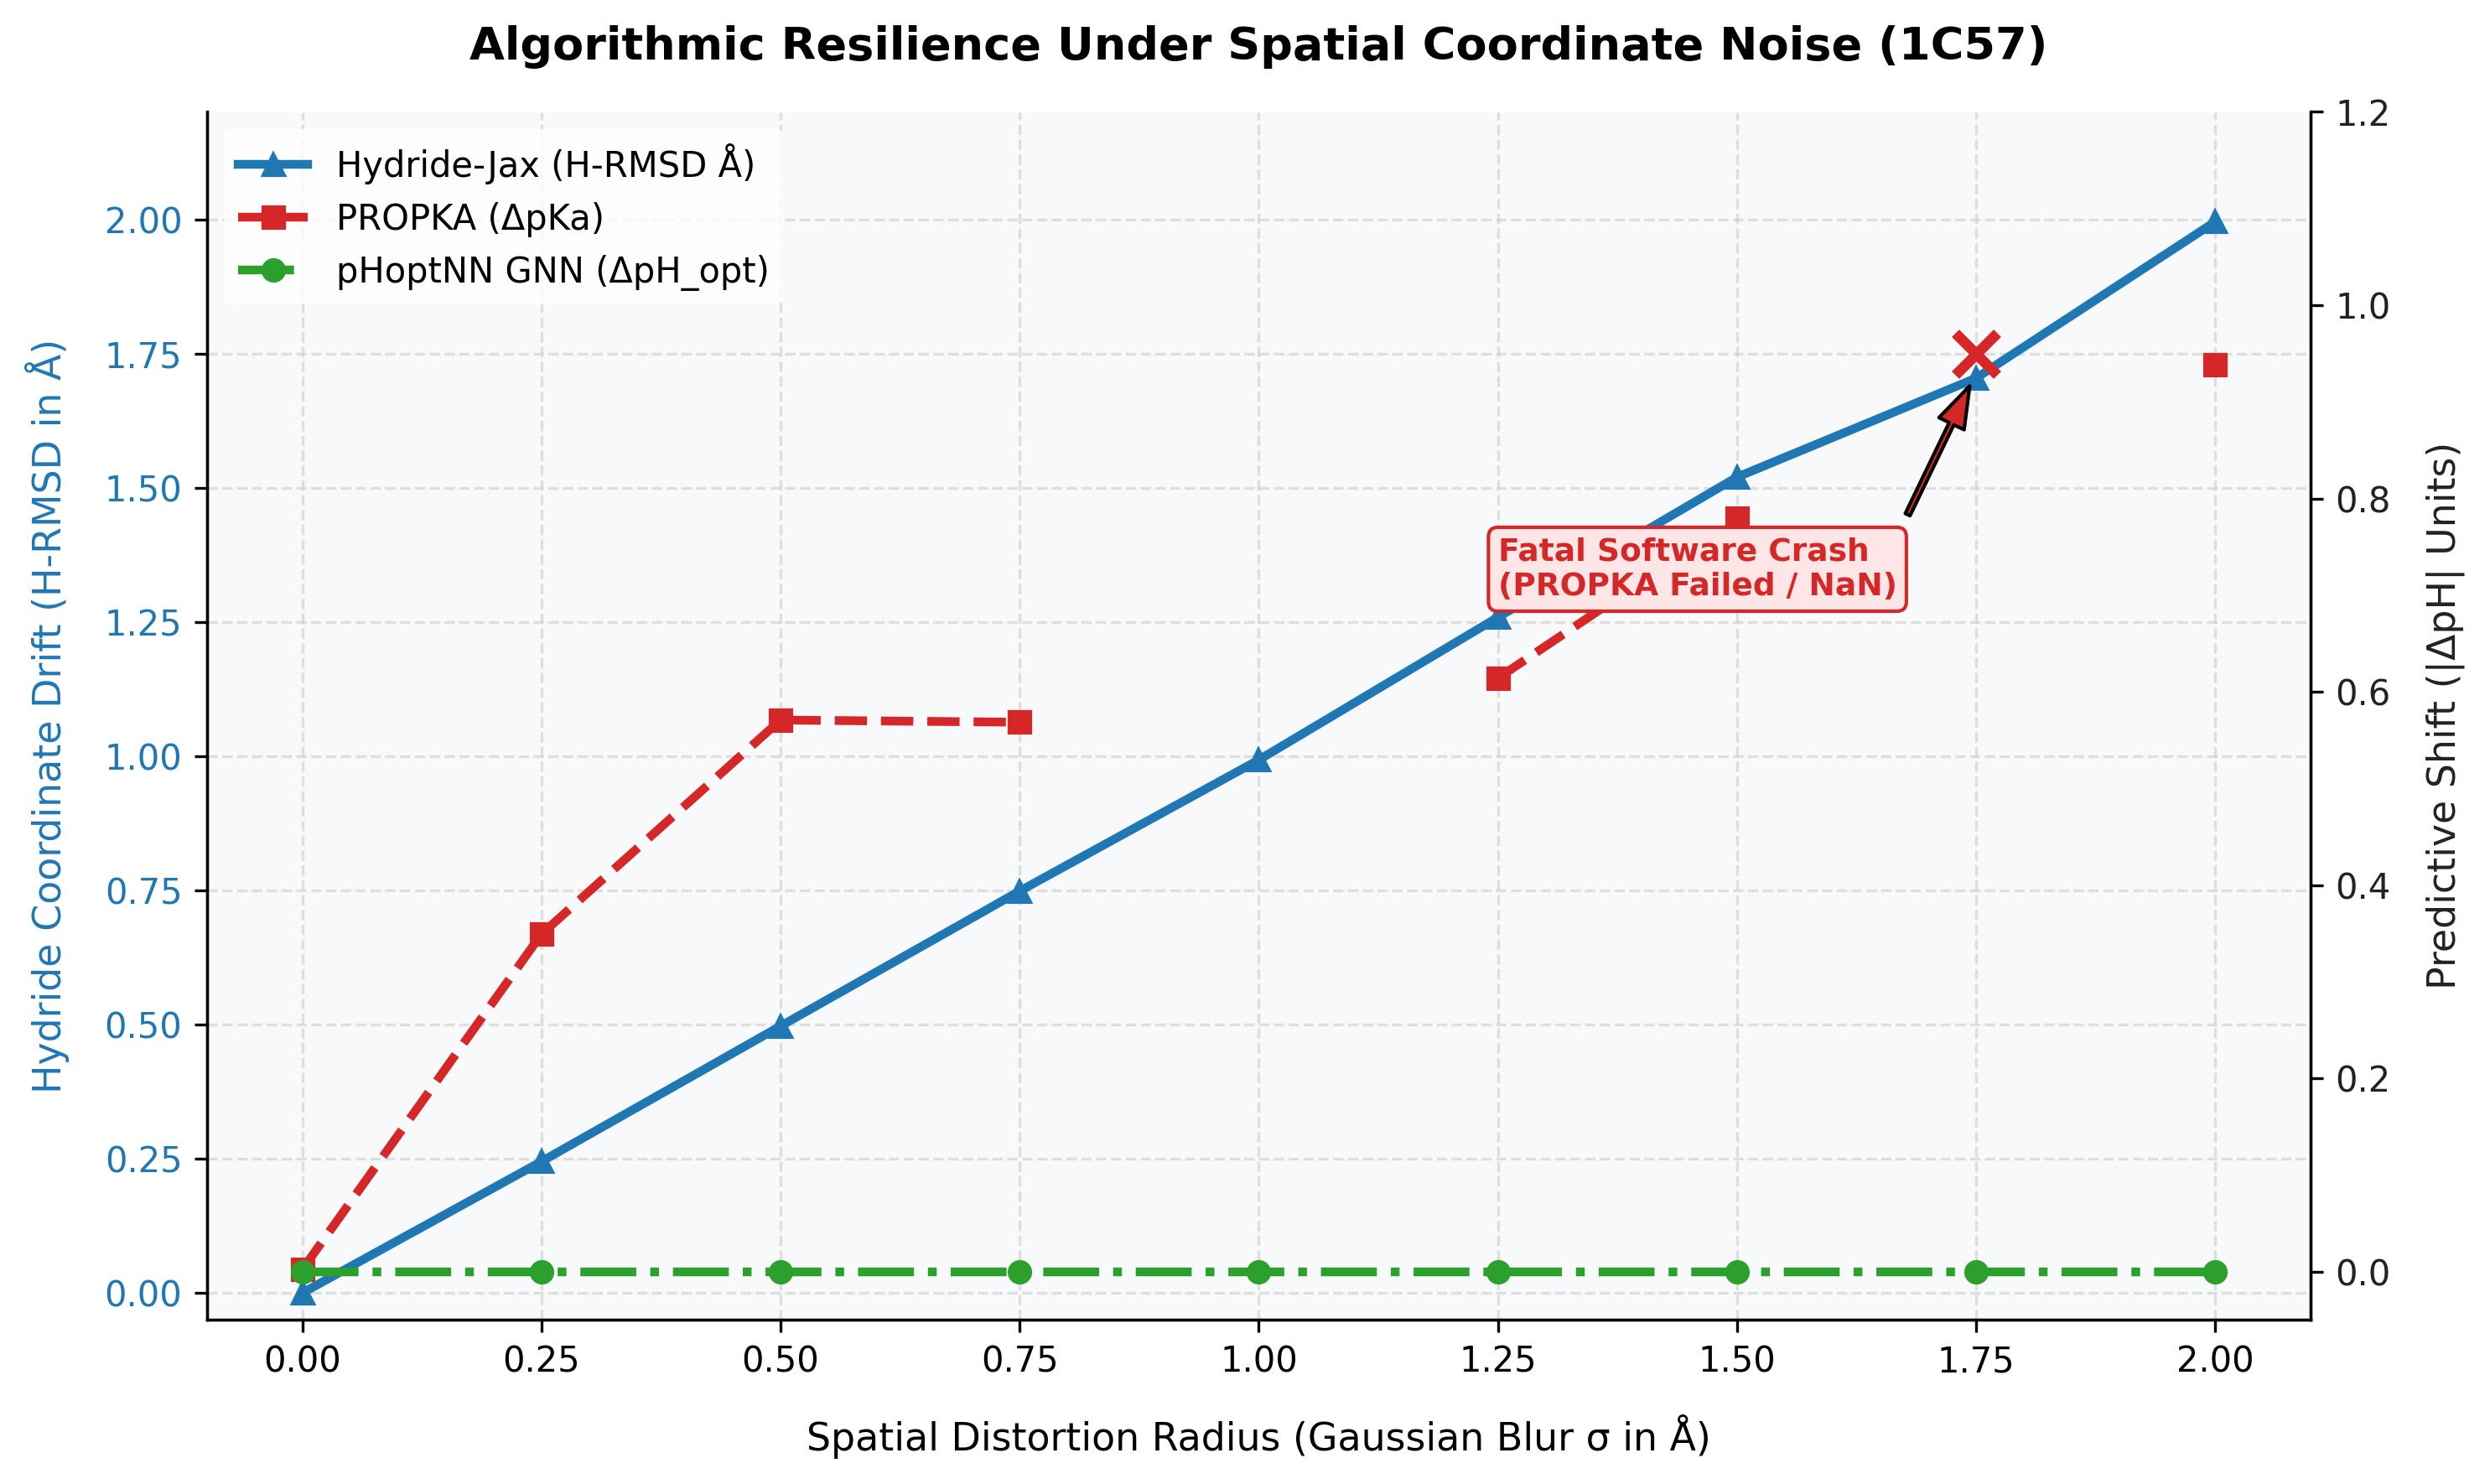

In [4]:
import matplotlib.pyplot as plt

plt.close('all')

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
ax1.set_facecolor('#f8f9fa')
ax1.grid(True, linestyle='--', alpha=0.6, color='#cccccc')

# Create secondary Y-axis for pH metrics (PROPKA & pHoptNN pH)
ax2 = ax1.twinx()

# 1. Hydride H-RMSD (Left Y-Axis: Coordinates in Å)
line_hydride = ax1.plot(
    df_final["Stress (Blur Radius Å)"], 
    df_final["Hydride H-RMSD (Å)"], 
    label="Hydride-Jax (H-RMSD Å)", 
    color="#1f77b4", 
    linewidth=2.5, 
    marker='^', 
    linestyle='-'
)

# 2. PROPKA pH (Right Y-Axis: pH units)
line_propka = ax2.plot(
    df_final["Stress (Blur Radius Å)"], 
    df_final["PROPKA pKa Error (ΔpH)"], 
    label="PROPKA (ΔpKa)", 
    color="#d62728", 
    linewidth=2.5, 
    marker='s', 
    linestyle='--'
)

# 3. pHoptNN pH_opt (Right Y-Axis: pH units)
line_phoptnn = ax2.plot(
    df_final["Stress (Blur Radius Å)"], 
    df_final["pHoptNN Error"], 
    label="pHoptNN GNN (ΔpH_opt)", 
    color="#2ca02c", 
    linewidth=2.5, 
    marker='o', 
    linestyle='-.'
)

# Crash annotation for PROPKA at 1.75Å
crash_x = 1.75
ax2.plot(crash_x, 0.95, marker='x', markersize=12, markeredgewidth=3, color='#d62728')
ax2.annotate(
    'Fatal Software Crash\n(PROPKA Failed / NaN)', 
    xy=(crash_x, 0.93), 
    xytext=(1.25, 0.70),
    arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=8),
    fontsize=9, 
    fontweight='bold', 
    color='#d62728',
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffe6e6", ec="#d62728", lw=1)
)

# Formatting
ax1.set_title("Algorithmic Resilience Under Spatial Coordinate Noise (1C57)", fontsize=13, pad=15, fontweight='bold')
ax1.set_xlabel("Spatial Distortion Radius (Gaussian Blur σ in Å)", fontsize=11, labelpad=10)

ax1.set_ylabel("Hydride Coordinate Drift (H-RMSD in Å)", fontsize=11, labelpad=10, color="#1f77b4")
ax2.set_ylabel("Predictive Shift (|ΔpH| Units)", fontsize=11, labelpad=10, color="#222222")

ax1.tick_params(axis='y', labelcolor="#1f77b4")
ax2.tick_params(axis='y', labelcolor="#222222")

ax1.set_xlim(-0.1, 2.1)
ax1.set_ylim(-0.05, 2.2)
ax2.set_ylim(-0.05, 1.2)

# Combined Legend
lines = line_hydride + line_propka + line_phoptnn
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=True, facecolor='white', edgecolor='none', loc='upper left')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

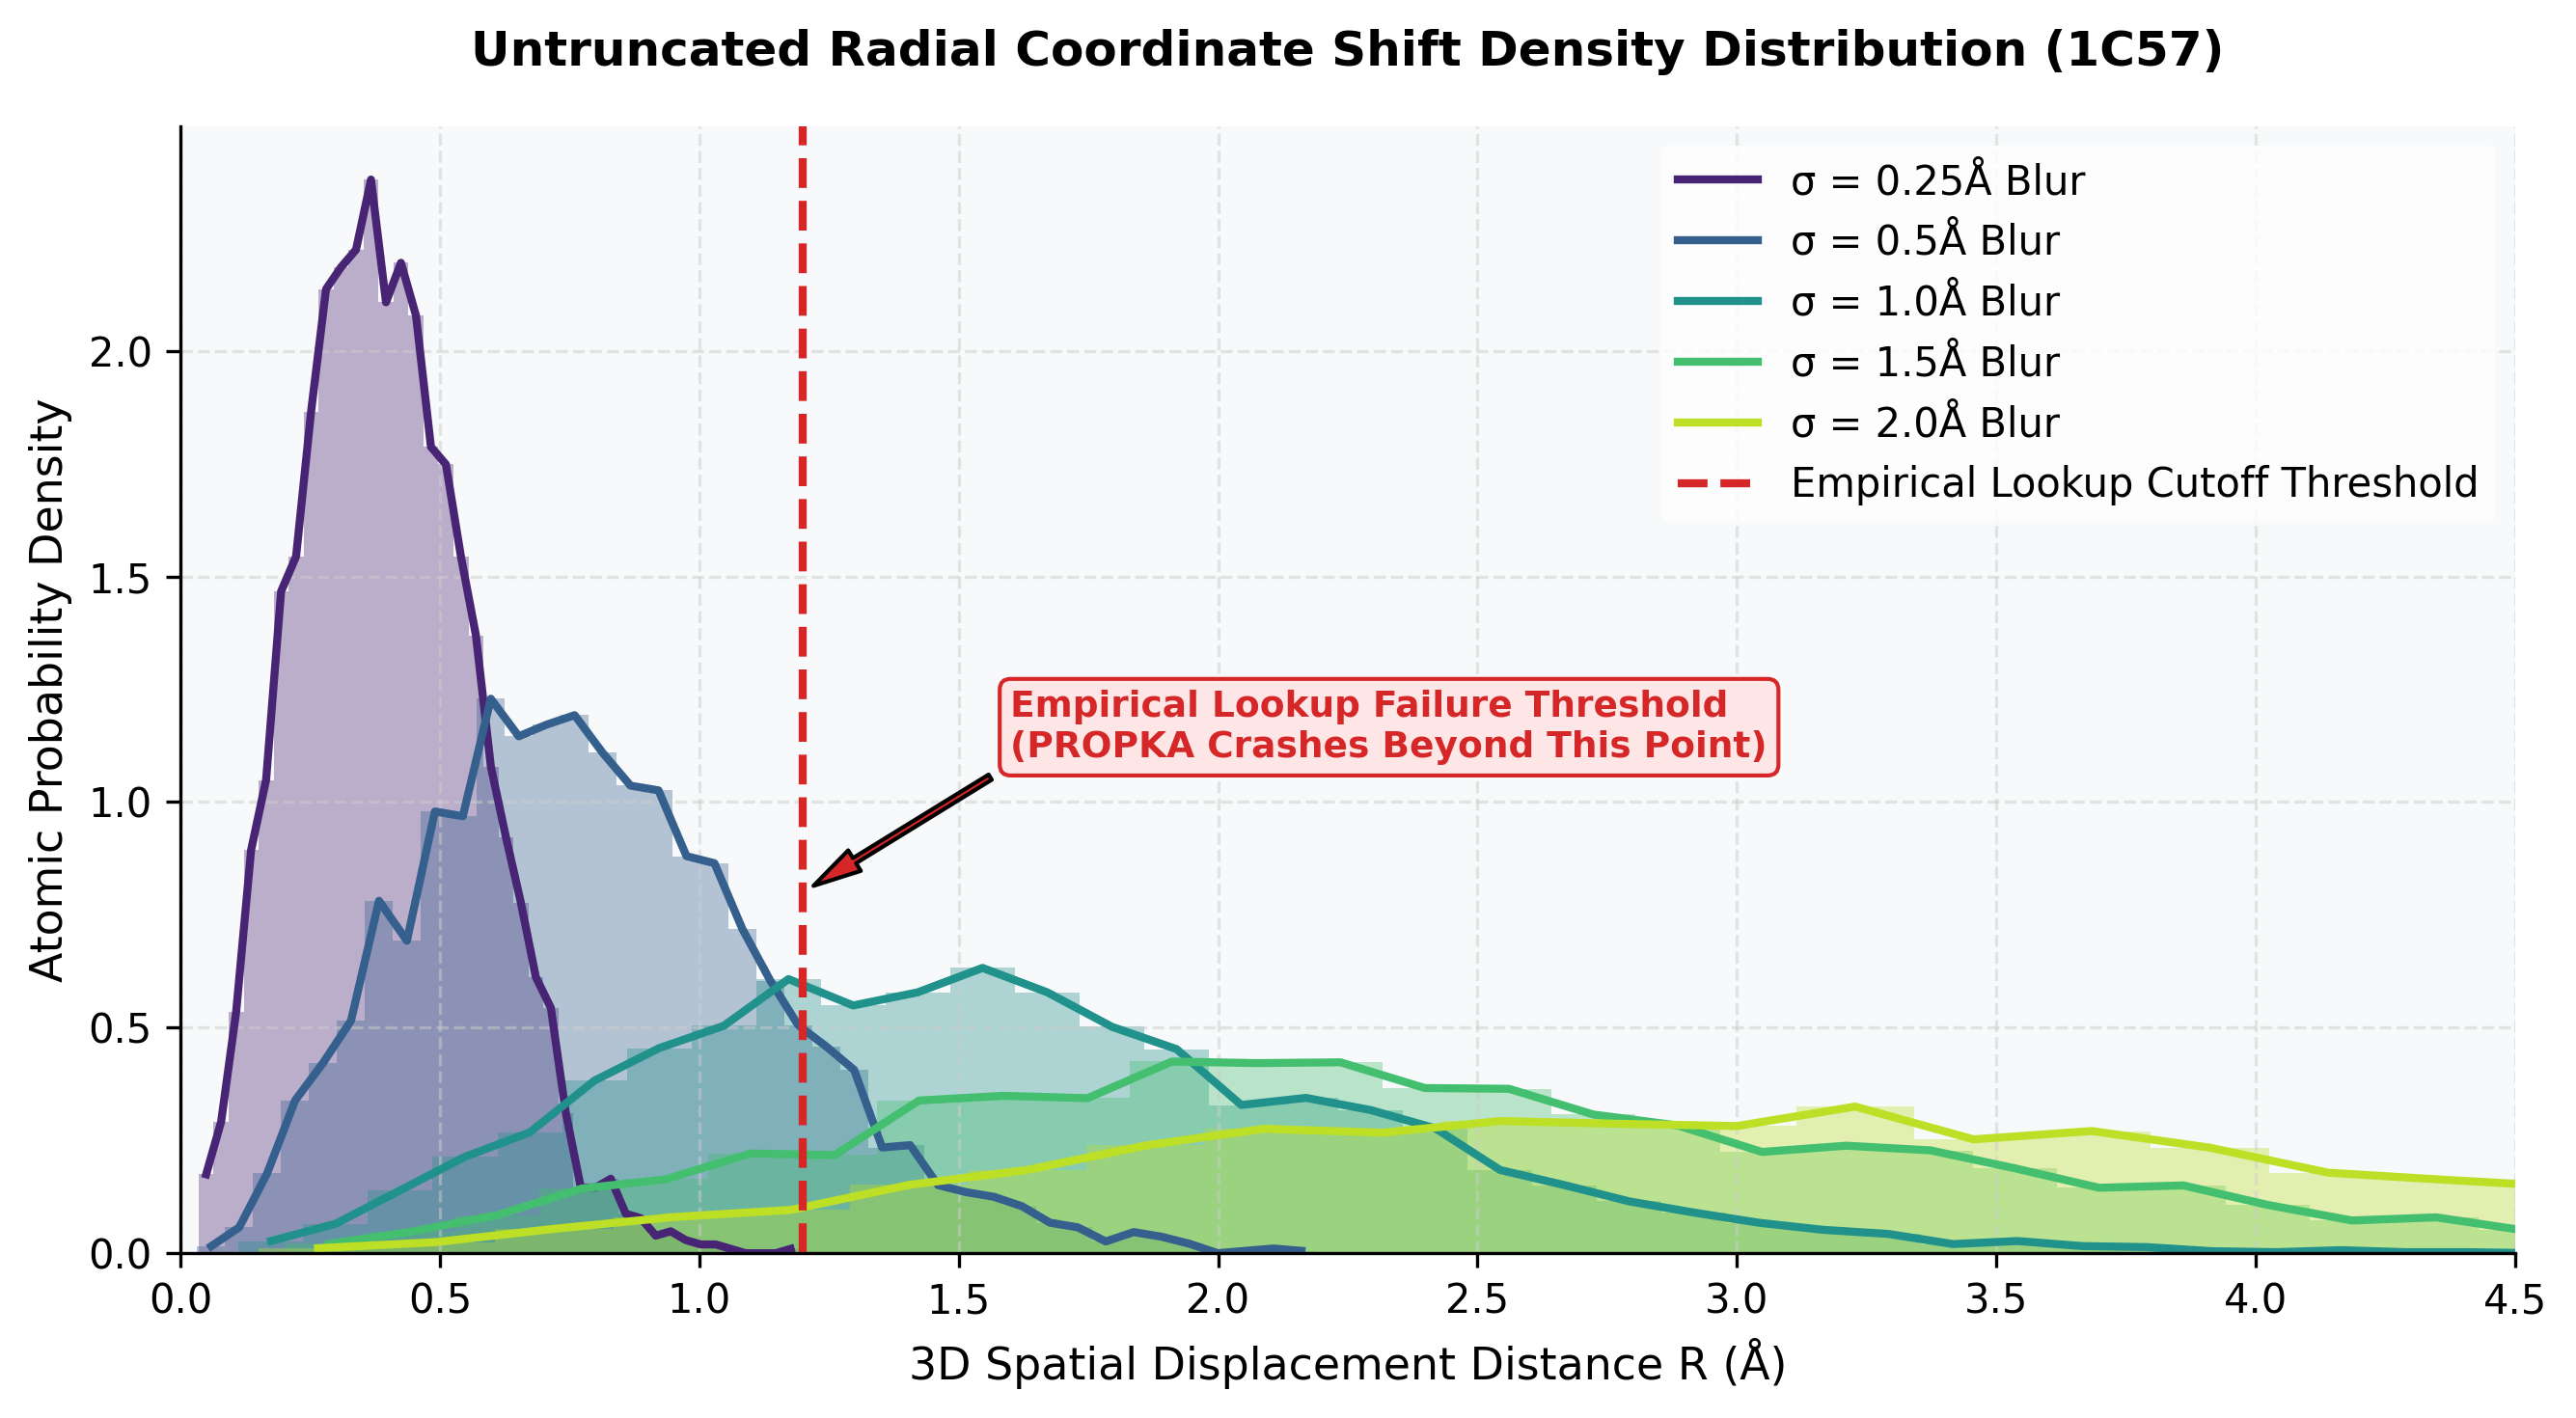

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from biopandas.pdb import PandasPdb

def generate_untruncated_radial_histogram(ground_truth_pdb="1c57.pdb"):
    # Load pristine coordinates
    ppdb_ref = PandasPdb().read_pdb(ground_truth_pdb)
    ref_df = ppdb_ref.df['ATOM']
    ref_coords = ref_df[['x_coord', 'y_coord', 'z_coord']].values
    num_atoms = len(ref_coords)

    stress_levels = [0.25, 0.5, 1.0, 1.5, 2.0]
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stress_levels)))

    fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')

    for sigma, color in zip(stress_levels, colors):
        # Generate 3D Gaussian spatial noise across X, Y, Z
        noise_xyz = np.random.normal(0, sigma, size=ref_coords.shape)
        
        # Calculate untruncated 3D radial displacement for every atom
        # R = sqrt(dx^2 + dy^2 + dz^2)
        radial_displacements = np.linalg.norm(noise_xyz, axis=1)

        # Plot KDE/Histogram density curve
        ax.hist(
            radial_displacements, 
            bins=40, 
            density=True, 
            alpha=0.35, 
            color=color
        )
        
        # Smooth line outline
        counts, bin_edges = np.histogram(radial_displacements, bins=40, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.plot(bin_centers, counts, color=color, linewidth=2, label=f'σ = {sigma}Å Blur')

    # standard empirical Hydrogen bond cutoff (1.2Å to 1.5Å)
    ax.axvline(1.2, color='#d62728', linestyle='--', linewidth=2, label='Empirical Lookup Cutoff Threshold')
    
    # Annotate failure zone
    ax.annotate(
        'Empirical Lookup Failure Threshold\n(PROPKA Crashes Beyond This Point)', 
        xy=(1.2, 0.8), 
        xytext=(1.6, 1.1),
        arrowprops=dict(facecolor='#d62728', shrink=0.05, width=1.5, headwidth=6),
        fontsize=9, 
        fontweight='bold', 
        color='#d62728',
        bbox=dict(boxstyle="round,pad=0.3", fc="#ffe6e6", ec="#d62728", lw=1)
    )

    ax.set_title("Untruncated Radial Coordinate Shift Density Distribution (1C57)", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("3D Spatial Displacement Distance R (Å)", fontsize=11)
    ax.set_ylabel("Atomic Probability Density", fontsize=11)
    ax.set_xlim(0, 4.5)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right')
    plt.tight_layout()
    plt.savefig("untruncated_radial_histogram.png")
    plt.show()


generate_untruncated_radial_histogram()